This notebook records the creation of the `SHENDURE_BOUNDS` preset object and some plots illustrating modeling choices.

Setup.

In [ ]:
import sys
import os
import scMPRAforge as scm
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import norm

#load the autoreload extension
%load_ext autoreload
#reload code on every execution
#(this may break objects)
#you can remove this & do dev in a notebook, then paste into the module when you are done.
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
from dask.distributed import Client, LocalCluster
cluster=LocalCluster(memory_limit='8GB')
client=Client(cluster)

Load shendure ortho object.

In [18]:
path="/gpfs/gibbs/pi/reilly/tabula_data/shendure"
name="ortho_primordial_v3"
data_root="/gpfs/gibbs/pi/reilly/tabula_data"
primordial=scm.ortho.load(client,path,name)

Let's take a look at the transfection efficiency as proxied by number of different MPRA barcodes detected per cell.

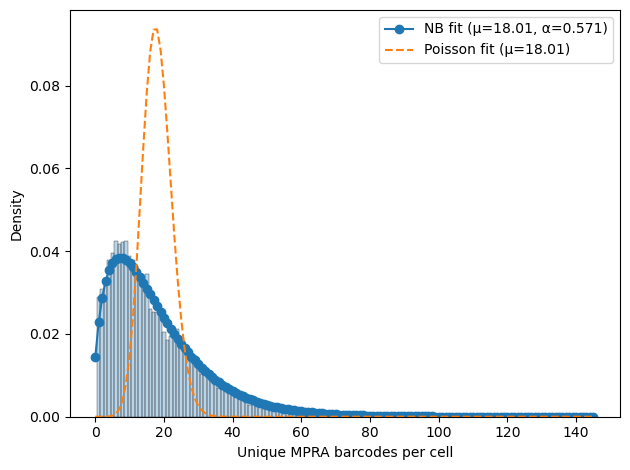

{'poisson_mu': 18.01055567079212,
 'nb_mu': 18.010555670792133,
 'nb_alpha': 0.5705626300443596}

In [19]:
primordial.training_data.describe_transfection(plot=True)

In [20]:
shendure_bounds=scm.Bounds.from_ortho(primordial)

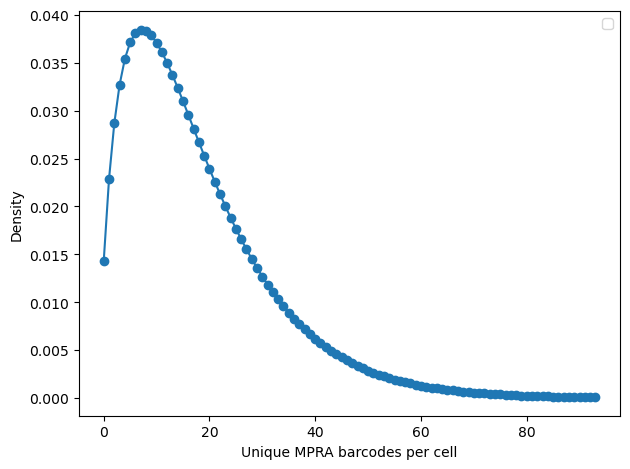

In [21]:
shendure_bounds.plot_transfection()

Now let's look a library composition : MPRA barcodes per CRE.

Normally distributed?

In [28]:
import matplotlib.pyplot as plt

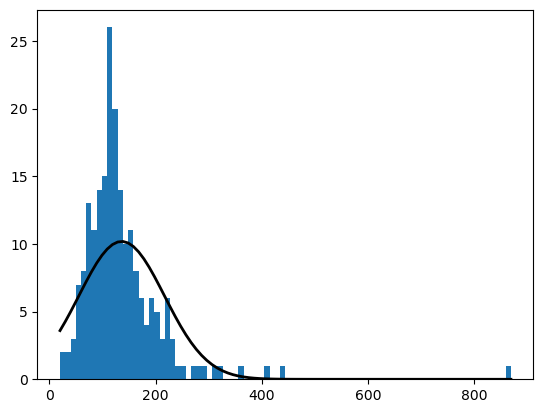

In [ ]:
data = shendure_bounds.MPRA_barcodes_per_CRE

#fit a normal distribution
mu, std = norm.fit(data)

#plot real data
counts, bins, _ = plt.hist(data, bins=int(data.max()/10))

#plot model
x = np.linspace(bins[0], bins[-1], len(bins))
p = norm.pdf(x, mu, std)

bin_width = bins[1] - bins[0]
p_scaled = p * len(data) * bin_width

plt.plot(x, p_scaled, 'k', linewidth=2)
plt.show()

Not normally distributed. We could maybe get better results with a truncated norm, but let's try poisson and NB first. The data generating process is counting like and looks pretty poission-y in some published stuff. 

In [71]:
import statsmodels.api as sm
from scipy.stats import poisson, nbinom

In [76]:
import statsmodels.api as sm
import statsmodels.discrete.discrete_model as smd

In [ ]:
y = np.asarray(data, dtype=int)
# intercept-only design
X = np.ones((len(y), 1))

pois = smd.Poisson(y, X).fit(disp=False)
mu_pois = np.exp(pois.params[0])

# plot


In [15]:
shendure_bounds.to_tgz("scMPRAforge/presets/shendure_bounds.tgz")

In [ ]:
cluster.close()